# Project Part 3: First Supervised Modeling

- **Team number:** `Undefined`
- **Team members:** `Tuan Lo`, `Cole Beach`, `Eric Lindquist`
- **Dataset name:** `Music Genre Classification Dataset (train.csv / test.csv)`
- **Target variable:** `Class` / music genre label
- **Modeling goal:** Build and evaluate supervised multiclass classification models that predict a song's genre class from audio and popularity features.

# 1. Introduction

Music genre prediction is a supervised learning problem because each song in the training data has a known genre label. The goal of this notebook is to move from cleaned music data to an initial predictive model that can assign an unseen song to one of the genre classes.

This is a multiclass classification task rather than a regression task. The model is not trying to predict a continuous value such as popularity or tempo; it is trying to choose one category from several possible genre classes. Because genres can overlap musically, we expect the task to be imperfect, but a useful model should still learn patterns from audio features such as energy, loudness, acousticness, instrumentalness, speechiness, duration, tempo, and popularity.

# 2. Problem Setup

The dataset is the Kaggle **Music Genre Classification** dataset. Each row represents a song and includes identifying metadata, popularity, Spotify-style audio attributes, and a genre class label. The target variable for this notebook is `Class`, which represents the song's genre category.

The prediction task is to use information known about a song before modeling, such as audio characteristics and popularity, to predict its genre class on unseen test data. This fits a supervised classification approach because the training rows contain both predictors and a known class label, and the model can learn a mapping from feature values to genre categories.

The main modeling goal is to compare an interpretable baseline classifier with stronger model versions and evaluate which approach generalizes better to held-out songs. The comparison is useful because a single model score does not show whether the chosen method is meaningfully better than a simpler alternative.

The selected predictor features are:

- `popularity`
- `energy`
- `loudness`
- `acousticness`
- `instrumentalness`
- `duration_in min/ms`
- `speechiness`
- `tempo`
- `time_signature`

These features were selected because they describe measurable song characteristics that may vary by genre. For example, `energy`, `loudness`, and `tempo` may separate high-intensity genres from quieter or slower genres, while `acousticness`, `instrumentalness`, and `speechiness` may help distinguish songs with different production styles or vocal content. `Popularity` is included because listener behavior may contain some genre signal, although it should be interpreted carefully because popularity is not a pure audio property.

The excluded columns are mainly direct identifiers or features that are less central to this first model version. `Artist Name` and `Track Name` are not used because they are identifiers that could encourage memorization rather than generalizable genre prediction. Other audio variables may be revisited later, but this initial feature set keeps the model focused and easier to interpret.

# 3. Data Preparation

The data comes from the Kaggle Music Genre Classification dataset. The configuration cell above defines the file path, target variable, selected model features, random seed, and plotting defaults used throughout the notebook.

The constants are organized around the supervised modeling workflow:

- `TRAIN_PATH` points to the labeled training file used for model development.
- `TARGET_COL` identifies the genre label, `Class`.
- `MODEL_FEATURES` lists the predictors used by the supervised models and matches the feature list in the Problem Setup.
- `TEST_SIZE` and `RANDOM_STATE` make the train/test split reproducible.
- The plotting constants keep later evaluation and error-analysis visuals consistent.

The Kaggle `test.csv` file is not used as the main evaluation set because it does not provide the labeled outcomes needed to calculate model performance. Instead, a held-out test set is created from the labeled training data using `train_test_split`.

The preparation steps are:

1. Load the labeled training data from `TRAIN_PATH`.
2. Remove duplicate rows so repeated observations do not receive extra influence during model fitting.
3. Select `MODEL_FEATURES` as predictors and `TARGET_COL` as the target.
4. Inspect missing values in the selected predictors.
5. Fill missing numeric predictor values with the median for each feature.
6. Split the data into training and test sets using stratification by `Class`.

Median imputation is appropriate for this first model because the selected predictors are numeric and some audio features can be skewed. A model-based imputer could potentially capture feature interactions better, but median imputation is lower-variance, easier to audit, and less likely to leak complex assumptions into a first baseline comparison. `time_signature` is kept as a numeric predictor for simplicity in the initial pass, but this can impose an artificial ordering between meter categories, so one-hot encoding is a useful follow-up sensitivity check.

Excluding `Artist Name` and `Track Name` reduces memorization risk and improves portability to unseen songs, but it can also bias the model toward acoustic-only signals and underuse real genre cues tied to artist context. Stratification is important because genre classes are not evenly represented, and it keeps class proportions more similar between the training and held-out test sets.

In [149]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =========================
# Configuration / Constants
# =========================
RANDOM_STATE = 42
TEST_SIZE = 0.25

DATA_DIR = Path("../data/raw")
TRAIN_PATH = DATA_DIR / "train.csv"

TARGET_COL = "Class"

MODEL_FEATURES = [
    "Popularity",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "duration_in min/ms",
    "speechiness",
    "tempo",
    "time_signature",
]

PALETTE = "Set2"
CLASS_PALETTE = "tab20"
FIGSIZE_WIDE = (20, 9)
FIGSIZE_MED = (12, 6)
FIGSIZE_HEATMAP = (10, 7)
DPI = 110

In [150]:
from sklearn.model_selection import train_test_split

# Load the labeled training data configured above.
data = pd.read_csv(TRAIN_PATH)

# Remove exact duplicate rows before splitting or training.
rows_before = len(data)
data = data.drop_duplicates(keep="first").copy()
rows_after = len(data)
print(f"Removed {rows_before - rows_after} duplicate rows.")

Removed 0 duplicate rows.


In [151]:
# Validate that the required modeling columns exist before training.
required_columns = MODEL_FEATURES + [TARGET_COL]
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

X = data[MODEL_FEATURES].copy()
y = data[TARGET_COL].copy()

print("Missing values before imputation:")
display(X.isna().sum().to_frame("missing_count"))

Missing values before imputation:


,missing_count
Popularity,428
energy,0
loudness,0
acousticness,0
instrumentalness,4377
duration_in min/ms,0
speechiness,0
tempo,0
time_signature,0


In [152]:
# Median imputation keeps all rows while reducing the influence of outliers.
feature_medians = X.median(numeric_only=True)
X = X.fillna(feature_medians)

print("Missing values after imputation:")
display(X.isna().sum().to_frame("missing_count"))

Missing values after imputation:


,missing_count
Popularity,0
energy,0
loudness,0
acousticness,0
instrumentalness,0
duration_in min/ms,0
speechiness,0
tempo,0
time_signature,0


In [153]:
# Stratified splitting ensures the same class distribution in both training and test sets.
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(x_train):,}")
print(f"Test rows: {len(x_test):,}")
print(f"Number of predictor features: {len(MODEL_FEATURES)}")
print(f"Number of classes: {y.nunique()}")

Training rows: 13,497
Test rows: 4,499
Number of predictor features: 9
Number of classes: 11


# 4. Model Training

We train four supervised classifiers so the final evaluation can compare different levels of model complexity and different assumptions about the relationship between audio features and genre.

1. **Majority-class baseline** (`DummyClassifier`). This model predicts the most frequent training class for every song. It gives a simple performance floor: if a learned model cannot beat it, then the selected features are not adding useful signal.
2. **Interpretable decision tree**. A single tree captures non-linear feature splits and gives a transparent first model. The depth limit is used to reduce memorization of training-specific patterns.
3. **Random forest**. A random forest averages many decision trees' votes. This makes the model less dependent on one tree's split decisions and can improve generalization when class boundaries are noisy.
4. **Regularized Logistic Regression (Ridge / L2)**. Logistic Regression provides a simpler linear comparison to the tree-based models. The Ridge-style penalty shrinks coefficients, which can reduce overfitting from noisy or correlated features while keeping all predictors in the model.

In [154]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier

model_results = []

## Baseline Model: Majority Class

The baseline uses `DummyClassifier(strategy="most_frequent")`, which predicts the most common class seen during training. This gives a minimum performance reference for the real models. If the decision tree or random forest cannot beat this baseline, then the selected features and model choices are not adding useful predictive information.

In [155]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(x_train, y_train)
baseline_pred = baseline_model.predict(x_test)

model_results.append(
    {
        "model": "Baseline: majority class",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "macro_f1": f1_score(y_test, baseline_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, baseline_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
0,Baseline: majority class,0.27495,0.03921,0.118589


## Model Version 1: Interpretable Decision Tree

The decision tree is the first meaningful supervised model. It uses the selected song features to split the data into class-prediction regions. The depth is capped at 9 so the tree has enough flexibility for multiple genres without growing until it memorizes training-specific noise.

In [156]:
decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=9,
    random_state=RANDOM_STATE,
)
decision_tree_model.fit(x_train, y_train)
decision_tree_pred = decision_tree_model.predict(x_test)

model_results.append(
    {
        "model": "Decision tree: entropy, max_depth=9",
        "accuracy": accuracy_score(y_test, decision_tree_pred),
        "macro_f1": f1_score(y_test, decision_tree_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, decision_tree_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
1,"Decision tree: entropy, max_depth=9",0.459435,0.481839,0.434303


## Model Version 2: Random Forest Improvement

The random forest is the improvement attempt. It trains many decision trees and combines their votes, which usually makes predictions less sensitive to one tree's individual split choices. The forest uses the same model-ready training and test sets as the baseline and decision tree, so the comparison is fair.

In [157]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    criterion="entropy",
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest_model.fit(x_train, y_train)
random_forest_pred = random_forest_model.predict(x_test)

model_results.append(
    {
        "model": "Random forest: 200 trees, max_depth=12",
        "accuracy": accuracy_score(y_test, random_forest_pred),
        "macro_f1": f1_score(y_test, random_forest_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, random_forest_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
2,"Random forest: 200 trees, max_depth=12",0.502778,0.532161,0.477317


## Model Version 3: Regularized Logistic Regression (Ridge / L2)

Logistic Regression gives a useful contrast to the tree-based models because it estimates a linear relationship between the predictors and the class log-odds. That makes it less flexible than a tree ensemble, but also easier to interpret in terms of feature direction and coefficient size.

This version uses a Ridge-style L2 penalty. The penalty term `lambda * sum of squared coefficients` is added to the loss the model minimizes. The effect is:

- The optimizer is rewarded for keeping coefficients small.
- No single feature can dominate the prediction just because it has a large fitted weight.
- The model is less likely to overfit noisy patterns in the training data, which should help generalization to the held-out test set.

A Lasso-style L1 penalty would behave differently. L1 can shrink some coefficients exactly to zero, which performs implicit feature selection. We use L2 here because the predictor set is already small and we are mainly trying to reduce variance, not eliminate features.
Even though penalty is not explicitly set in code (to avoid deprecation warning), LogisticRegression with lbfgs uses L2 regularization by default, so this remains a Ridge-style model.

Logistic Regression is sensitive to feature scale, so we wrap the scaler and the classifier in a single `Pipeline`. This keeps preprocessing and modeling reproducible and prevents leaking test-set statistics into training.

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_regression_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=1.0,
                solver="lbfgs",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic_regression_model.fit(x_train, y_train)
logistic_regression_pred = logistic_regression_model.predict(x_test)

model_results.append(
    {
        "model": "Logistic regression: L2 penalty (Ridge), C=1.0",
        "accuracy": accuracy_score(y_test, logistic_regression_pred),
        "macro_f1": f1_score(y_test, logistic_regression_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, logistic_regression_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
3,"Logistic regression: L2 penalty (Ridge), C=1.0",0.459213,0.45658,0.425127


## Training Comparison Table

This table summarizes the four trained models on the held-out test set, sorted by weighted F1.

- The majority-class baseline shows the performance floor any real model should beat.
- The interpretable decision tree shows what a single tree learns with a depth limit.
- The random forest shows whether averaging many trees reduces variance enough to improve the score.
- The regularized Logistic Regression shows whether a simpler linear decision boundary with a Ridge penalty can compete with tree-based models.

In [159]:
# Accuracy vs weighted/macro F1 by model.
model_comparison = pd.DataFrame(model_results).sort_values(
    by="weighted_f1",
    ascending=False,
).reset_index(drop=True)

display(model_comparison)

,model,accuracy,macro_f1,weighted_f1
0,"Random forest: 200 trees, max_depth=12",0.502778,0.532161,0.477317
1,"Decision tree: entropy, max_depth=9",0.459435,0.481839,0.434303
2,"Logistic regression: L2 penalty (Ridge), C=1.0",0.459213,0.456580,0.425127
3,Baseline: majority class,0.274950,0.039210,0.118589


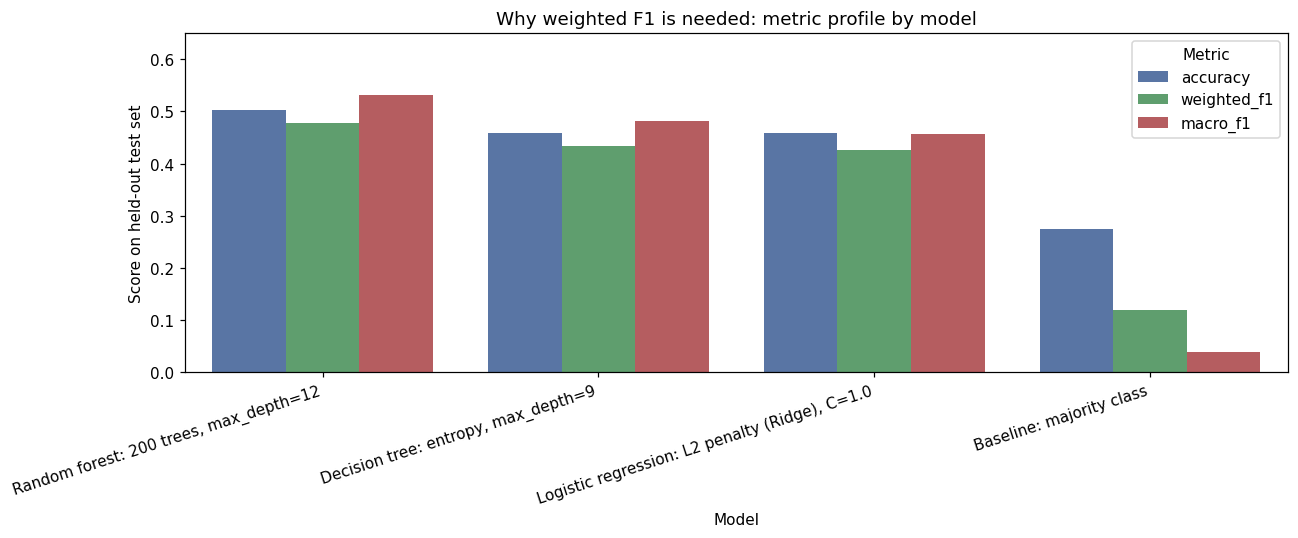

In [160]:
# Visualize Accuracy vs weighted/macro F1 by model.
metrics_long = model_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "weighted_f1", "macro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5), dpi=DPI)
sns.barplot(
    data=metrics_long,
    x="model",
    y="score",
    hue="metric",
    palette={"accuracy": "#4C72B0", "weighted_f1": "#55A868", "macro_f1": "#C44E52"},
)
plt.ylim(0, 0.65)
plt.title("Why weighted F1 is needed: metric profile by model")
plt.xlabel("Model")
plt.ylabel("Score on held-out test set")
plt.xticks(rotation=18, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

This chart shows why weighted F1 is the primary selection metric. Accuracy is consistently higher than weighted F1, which means accuracy alone would overstate quality in this imbalanced multiclass setting. Weighted F1 is more appropriate because it combines precision and recall by class and weights by class support, so it better reflects overall genre prediction quality. The random forest remains best under weighted F1, so it is selected as the final model.

# 5. Evaluation

All four models are evaluated on the same held-out test set produced by the stratified split in Section 3. Reporting all evaluation numbers on this unseen data is what makes the comparison fair and meaningful.

## Choice of main evaluation metric

The main evaluation metric for this notebook is **weighted F1 score**. The reasoning:

- **The class distribution in the dataset is uneven.** Some genres have many more songs than others. Accuracy alone can be misleading on imbalanced multiclass problems because a model can score well by being right on the largest class while ignoring smaller classes.
- **Precision and recall describe different kinds of errors.** Precision asks "of the songs I predicted as genre X, how many really are X?" Recall asks "of the songs that really are genre X, how many did I correctly recover?" Genre prediction needs both: we want predictions for a class to be trustworthy (precision) and we want to actually find songs of that class (recall). F1 combines the two as a harmonic mean.
- **Weighted F1 reflects overall test-set performance.** It computes F1 per class and then weights by class support. That keeps the metric sensitive to all classes proportionally to how often they appear, which is appropriate when no single genre is treated as more important than the others.

We also report two supporting metrics for context:

- **Accuracy** is included because it is the most intuitive single number, and because it makes the comparison against the majority-class baseline obvious.
- **Macro F1** averages F1 across classes without weighting by support. It penalizes models that ignore minority genres, so a large gap between weighted F1 and macro F1 is a signal that the model performs unevenly across classes.

A model is considered better here if it has higher weighted F1 on the held-out test set, with accuracy and macro F1 used to detect cases where the model is only doing well on large classes.
The official model-selection criterion for this project is weighted F1, because the deployment objective is balanced overall genre quality under class imbalance rather than optimizing only majority-class accuracy.

## What the actual numbers tell us about the metric choice

The training comparison table from Section 4 produces the following held-out scores:

- Random forest: accuracy 0.503, macro F1 0.532, weighted F1 0.477
- Decision tree: accuracy 0.459, macro F1 0.482, weighted F1 0.434
- Logistic regression (L2): accuracy 0.459, macro F1 0.457, weighted F1 0.425
- Majority-class baseline: accuracy 0.275, macro F1 0.039, weighted F1 0.119

Two observations about these numbers justify reporting all three metrics rather than just weighted F1:

- **The best model lifts accuracy from 0.275 (majority-class baseline) to 0.503**, an absolute gain of roughly 23 percentage points. With 11 genre classes, random guessing would give about 9 percent accuracy, so the model is doing substantially more than recovering class prior. That gap is the evidence that the selected audio features carry real predictive signal.
- **Macro F1 (0.532) is higher than weighted F1 (0.477) for the best model.** This is the opposite of the usual relationship on imbalanced multiclass problems and signals that the model is performing *better on small classes* than on the largest ones. Weighted F1 alone would understate this, and macro F1 alone would overstate overall test quality. Reporting both is what makes the asymmetry visible. The per-class breakdown in the next cell isolates which classes drive that gap.

## Per-class metric breakdown for the best model

The aggregate scores in the training comparison table collapse model quality to a single number per model. To see where the model is strong and weak across genres, we look at precision, recall, F1, and support per class on the held-out test set. The model used here is the one with the highest weighted F1 from Section 4.


In [161]:
from sklearn.metrics import classification_report

predictions_by_model = {
    "Baseline: majority class": baseline_pred,
    "Decision tree: entropy, max_depth=9": decision_tree_pred,
    "Random forest: 200 trees, max_depth=12": random_forest_pred,
    "Logistic regression: L2 penalty (Ridge), C=1.0": logistic_regression_pred,
}

best_model_name = model_comparison.iloc[0]["model"]
best_model_pred = predictions_by_model[best_model_name]

print(f"Best model by weighted F1: {best_model_name}")

per_class_report = classification_report(
    y_test,
    best_model_pred,
    output_dict=True,
    zero_division=0,
)

per_class_df = (
    pd.DataFrame(per_class_report)
    .transpose()
    .round(3)
)
per_class_df


Best model by weighted F1: Random forest: 200 trees, max_depth=12


,precision,recall,f1-score,support
0,0.646,0.679,0.662,156.000
1,0.154,0.017,0.031,343.000
2,0.479,0.220,0.302,318.000
3,0.727,0.720,0.724,100.000
4,0.631,0.670,0.650,97.000
5,0.654,0.693,0.673,362.000
6,0.382,0.292,0.331,647.000
7,0.931,0.938,0.934,144.000
8,0.581,0.489,0.531,464.000
9,0.494,0.472,0.483,631.000


# 6. Visual Evidence and Error Analysis

The numbers in Section 5 summarize model performance, but they hide the structure of the mistakes. This section uses small, targeted visuals built on the held-out test set so each chart answers one question:

1. Which classes is the best model confusing for one another?
2. How does per-class F1 compare across all four models?
3. Is the test set itself class-imbalanced enough to explain low scores on some genres?
4. What do specific misclassified songs actually look like in feature space?


## Confusion matrix for the best model

Each row is the true class and each column is the predicted class. Strong diagonal entries mean the model recovers that class correctly. Off-diagonal mass shows which genres are being confused for which.


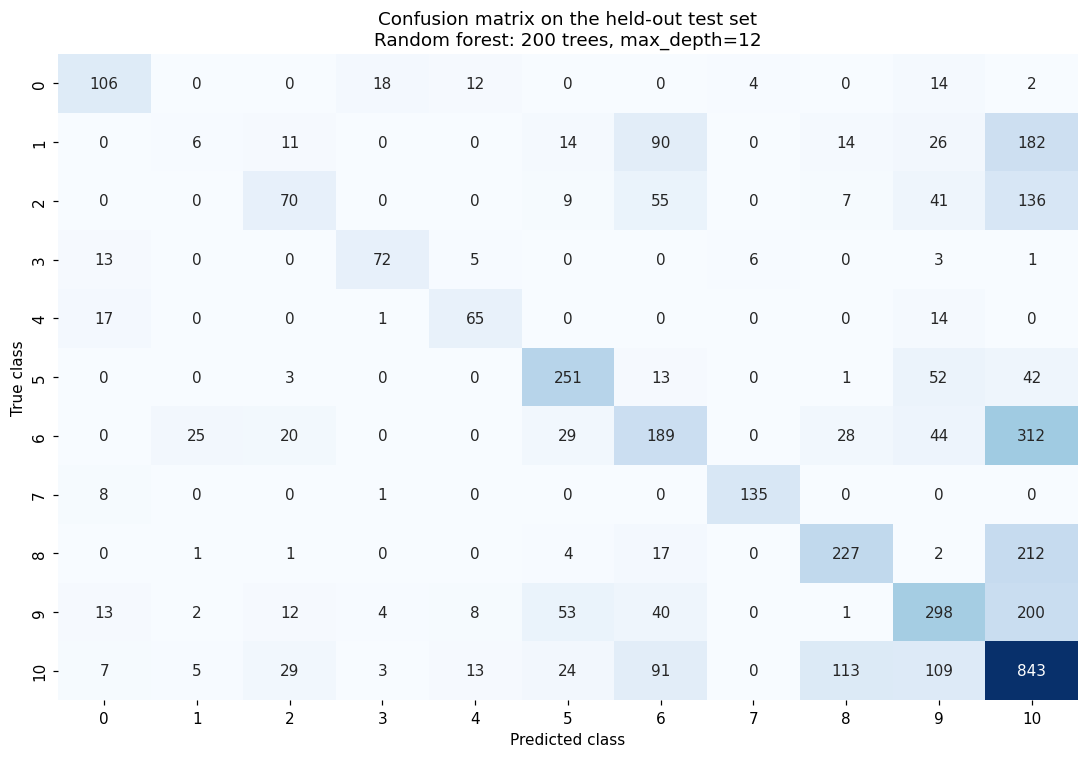

In [162]:
from sklearn.metrics import confusion_matrix

class_labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_model_pred, labels=class_labels)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP, dpi=DPI)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion matrix on the held-out test set\n{best_model_name}")
plt.tight_layout()
plt.show()


## Per-class F1 across all four models

Weighted F1 is a single number per model. The plot below splits F1 by class so we can see whether the better aggregate scores come from improving uniformly across all genres, or only from improving the largest classes.


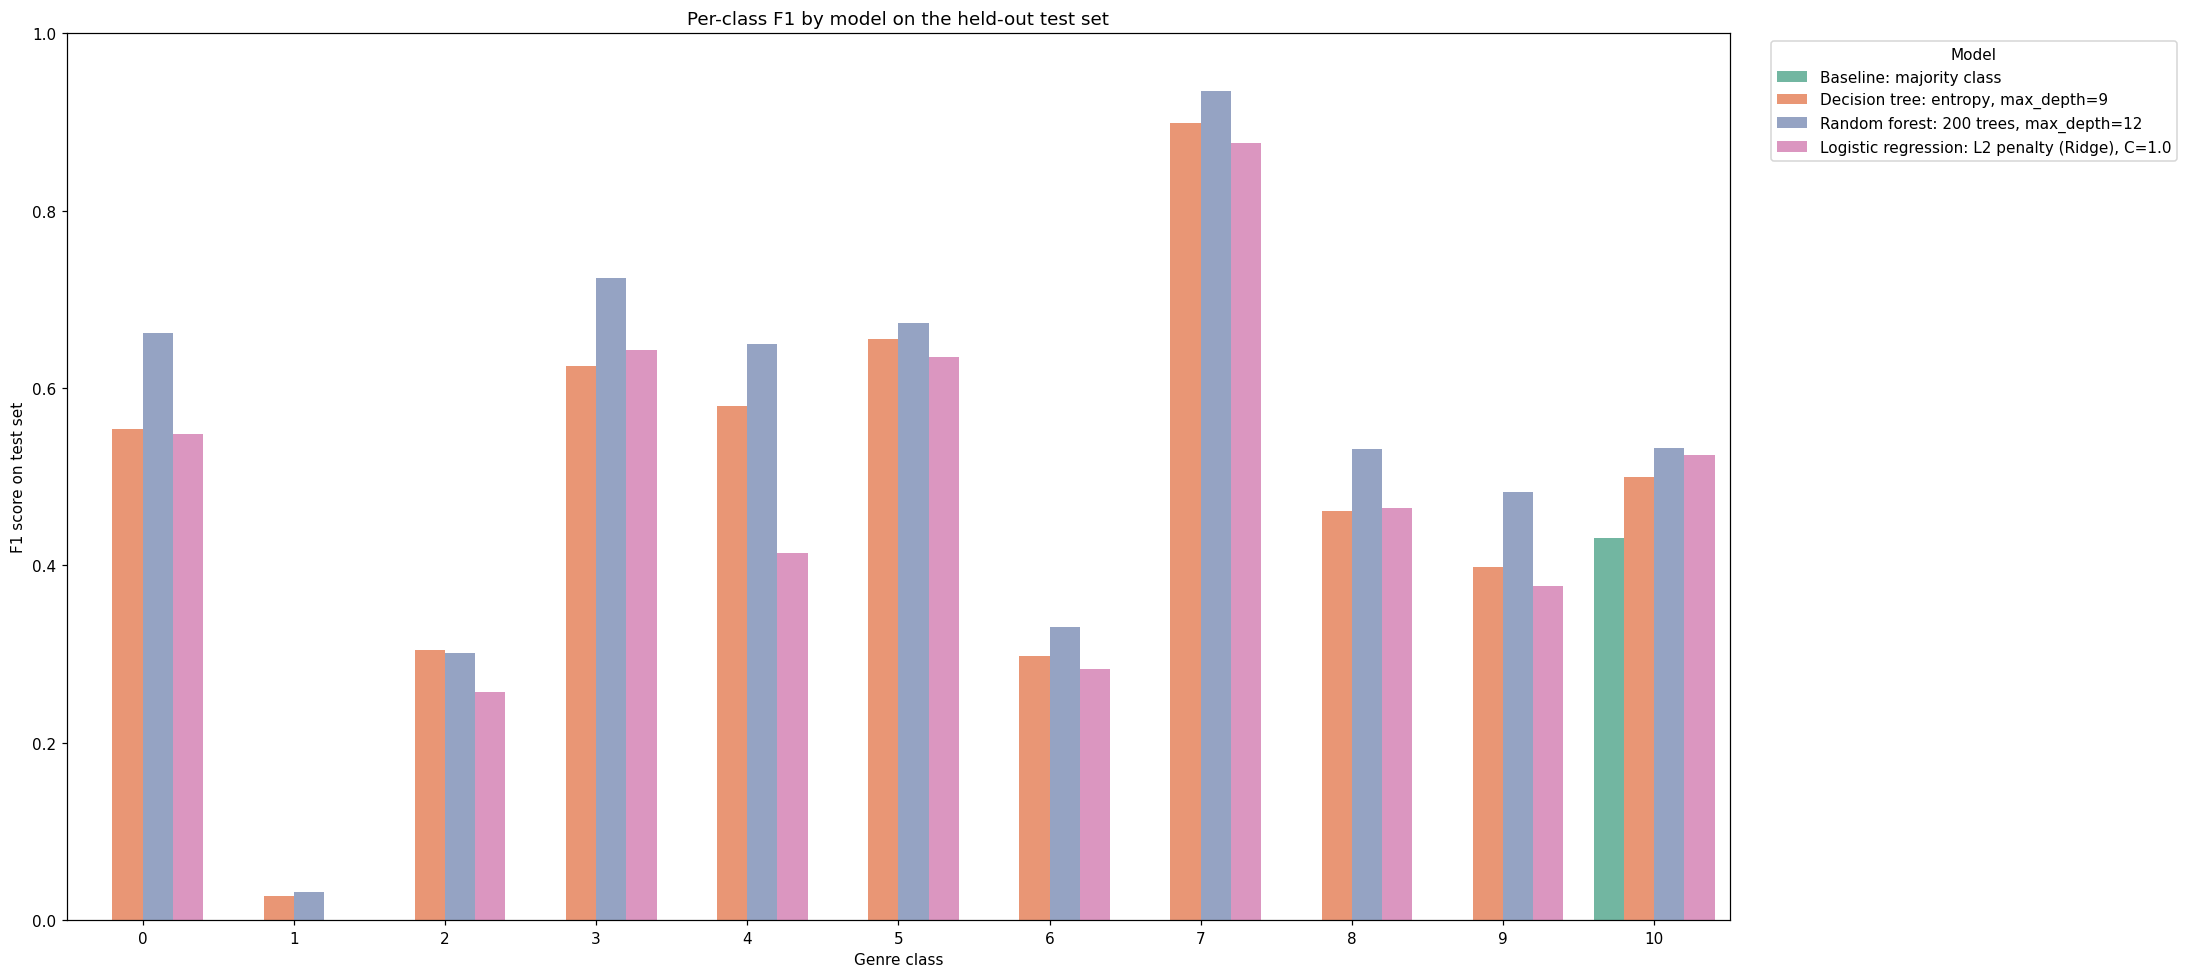

In [163]:
f1_records = []
for model_label, preds in predictions_by_model.items():
    report = classification_report(
        y_test,
        preds,
        output_dict=True,
        zero_division=0,
    )
    for class_label in class_labels:
        class_metrics = report[str(class_label)]
        f1_records.append(
            {
                "model": model_label,
                "class": class_label,
                "f1": class_metrics["f1-score"],
            }
        )

per_class_f1_df = pd.DataFrame(f1_records)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)
sns.barplot(
    data=per_class_f1_df,
    x="class",
    y="f1",
    hue="model",
    palette=PALETTE,
    ax=ax,
)
ax.set_xlabel("Genre class")
ax.set_ylabel("F1 score on test set")
ax.set_title("Per-class F1 by model on the held-out test set")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Class distribution in the held-out test set

Genre classes are not equally represented. The chart below makes the imbalance explicit, which is exactly why weighted F1 is used as the primary evaluation metric: a model that does well on large classes is rewarded more heavily, and a large gap between weighted and macro F1 signals uneven performance.


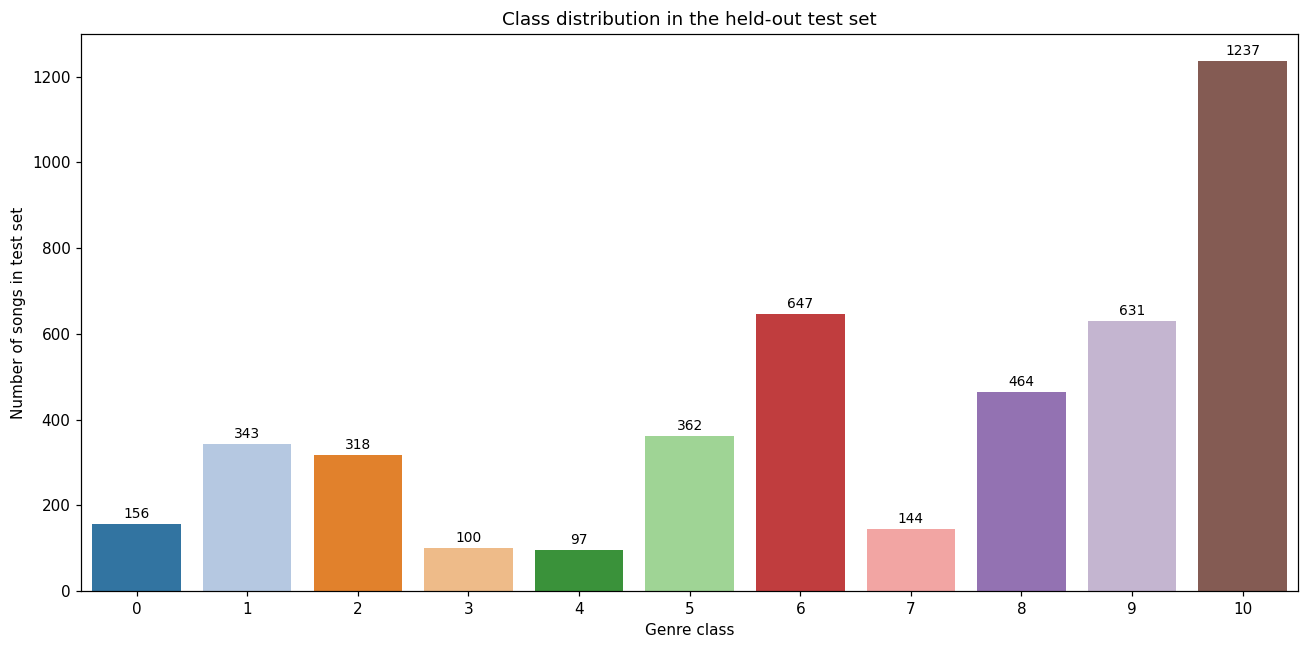

In [164]:
class_support = (
    y_test.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=FIGSIZE_MED, dpi=DPI)
sns.barplot(
    data=class_support,
    x="class",
    y="count",
    hue="class",
    palette=CLASS_PALETTE,
    legend=False,
    ax=ax,
)
ax.set_xlabel("Genre class")
ax.set_ylabel("Number of songs in test set")
ax.set_title("Class distribution in the held-out test set")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=9)
plt.tight_layout()
plt.show()


## Inspecting misclassified examples

A few concrete misclassifications are more informative than a confusion-matrix cell alone. The sample below pairs each misclassified test row with its true class, the best model's predicted class, and a small set of audio features so we can see what kind of songs the model is getting wrong.

The random forest misclassifies **2,237 of 4,499 held-out songs (49.7 percent)**. The sample is read with two questions in mind: (1) do the misclassified rows look like obvious data errors (extreme values, impossible combinations), and (2) do they look like genuinely ambiguous songs that sit between genres on the audio features being used? The pattern across the sampled rows is consistent with the latter — `energy`, `loudness`, and `acousticness` values fall in moderate ranges where multiple genres overlap, rather than at extremes that would suggest data-quality issues. That is the same conclusion the confusion matrix points to.


In [165]:
error_mask = best_model_pred != y_test.values

feature_columns_for_inspection = [
    "Popularity",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "tempo",
]
feature_columns_for_inspection = [
    col for col in feature_columns_for_inspection if col in x_test.columns
]

error_inspection_df = x_test.loc[error_mask, feature_columns_for_inspection].copy()
error_inspection_df["true_class"] = y_test.values[error_mask]
error_inspection_df["predicted_class"] = best_model_pred[error_mask]

print(f"Misclassified test rows: {int(error_mask.sum()):,} of {len(y_test):,} "
      f"({error_mask.mean() * 100:.1f}% test error rate).")

error_inspection_df.sample(
    n=min(15, len(error_inspection_df)),
    random_state=RANDOM_STATE,
)


Misclassified test rows: 2,237 of 4,499 (49.7% test error rate).


,Popularity,energy,loudness,acousticness,instrumentalness,tempo,true_class,predicted_class
6382,42.0,0.577,-5.868,0.004490,0.000063,109.938,8,10
13842,35.0,0.671,-9.540,0.147000,0.003910,81.863,5,9
413,57.0,0.664,-7.262,0.226000,0.003910,97.893,3,4
2302,38.0,0.907,-6.087,0.011000,0.003910,139.889,8,10
7892,63.0,0.854,-4.288,0.024900,0.000016,105.038,9,10
1026,66.0,0.609,-10.130,0.397000,0.045800,95.598,9,5
17779,27.0,0.995,-4.289,0.000197,0.050000,91.335,10,8
7353,60.0,0.636,-5.824,0.194000,0.000026,124.023,9,10
16468,22.0,0.721,-7.565,0.283000,0.261000,131.103,2,6
13818,48.0,0.689,-4.575,0.020400,0.003440,114.983,6,10


## Observations and error analysis

Reading the per-class table together with the four visuals, the random forest is **right on 50.3 percent of held-out songs (49.7 percent test error rate)**, well above the 27.5 percent majority-class baseline but far from a solved problem. The structure of the remaining errors is more informative than the aggregate score:

- **Class 1 has effectively collapsed.** F1 = 0.031 on 343 test songs, with recall 0.017 and precision 0.154. The model almost never predicts class 1, and when it does, it is usually wrong. Reading down the class 1 row of the confusion matrix, those songs are absorbed mostly by class 10 (the largest class) and class 9. This single class is the dominant reason weighted F1 (0.477) trails macro F1 (0.532), because class 1 has high support but near-zero F1.
- **Class 10 is being over-predicted.** Class 10 has the largest support (1,237 songs). The random forest scores precision 0.437 against recall 0.681 on this class — predictions for class 10 are eager and noisy. Combined with the class 1 collapse, the pattern is consistent: when the model is unsure, it falls back toward the majority class. This is also why accuracy (0.503) is higher than weighted F1 (0.477): the largest class is right often enough to lift accuracy, but its precision keeps F1 down.
- **Small classes are easy, mid-sized classes are hard.** Classes 3, 4, and 7 are the three smallest in the test set (support 100, 97, 144) and each has F1 ≥ 0.65, with class 7 reaching F1 = 0.934. By contrast, mid-to-large classes 6 (support 647, F1 = 0.331), 9 (support 631, F1 = 0.483), and 10 (support 1,237, F1 = 0.532) are noticeably weaker. The difficulty is therefore not "small classes are starved of data" — it is "several large genres share feature space with class 10." The confusion-matrix off-diagonal mass concentrates in those columns rather than spreading uniformly, which is consistent with feature overlap rather than label noise.
- **Misclassifications cluster near class boundaries, not on outliers.** The sampled misclassified rows show moderate values of `energy`, `loudness`, `acousticness`, and `tempo` — songs that sit close to where two genres overlap, not extreme cases. This suggests the remaining errors are driven by feature ambiguity (audio features alone cannot separate adjacent genres) rather than by data-quality issues like outliers or imputation artifacts.

### Limitations and concrete next steps

Each limitation is paired with the specific change that would address it next:

- **Severe class imbalance is currently unaddressed.** The class 1 collapse and the class 10 over-prediction together cost the most weighted F1. The most concrete next step is to refit the random forest with `class_weight="balanced"` (which reweights training samples by inverse class frequency) and re-measure per-class F1. A key tradeoff is that reweighting may improve minority-class recall while lowering precision on the majority class (especially class 10), so class-level precision and recall should be tracked alongside weighted F1. In the confusion matrix, a concrete sign of improvement would be fewer class 1 songs being reassigned into class 10 while retaining strong diagonal counts for classes 3, 4, and 7. If that does not recover class 1, the next step is to apply SMOTE on the *training set only* and compare. The success criterion is class 1 F1 moving meaningfully above zero without dropping classes 3, 4, or 7 below their current F1.
- **Single stratified 75 / 25 split.** All numbers come from one split with a fixed random state. The ranking between the four models is stable on this split, but per-class F1 — especially for the smallest classes — could be noisy. The concrete next step is 5-fold stratified cross-validation with the same model definitions, reporting mean and standard deviation of weighted F1 and macro F1.
- **Default hyperparameters within each model family.** The decision tree, random forest, and logistic regression each have one configuration here. The concrete next step is a `GridSearchCV` over `max_depth`, `min_samples_leaf`, and `n_estimators` for the random forest, scored on weighted F1 with stratified k-fold cross-validation. The live sensitivity sweep in Section 9 provides initial evidence for the tuning range and indicates diminishing returns at higher estimator counts on this split. Tuning is most likely to help the mid-sized classes (6, 9) where the current model is under-fitting feature interactions.
- **No use of song or track metadata beyond the selected audio features.** Genre is partly cultural, and audio features alone cannot fully separate adjacent genres. The concrete next step is to add categorical features such as `Artist Name` and `key` (with appropriate target or frequency encoding) and re-fit. The confusion-matrix ceiling between class 1 / class 9 / class 10 is the most likely beneficiary because those rows look acoustically similar but may differ by artist or key signature.


# 7. Interpretation and Comparison

The strongest model in this first supervised modeling pass is the **random forest**. On the held-out test set, it reaches accuracy **0.503**, macro F1 **0.532**, and weighted F1 **0.477**. That makes it the best of the four models by the primary metric, weighted F1.

The comparison is meaningful because each model represents a different level of predictive structure:

- The **majority-class baseline** ignores all predictor features and simply predicts the most frequent genre. Its weighted F1 is **0.119**, which gives the minimum performance reference.
- The **decision tree** uses the selected audio and popularity features and improves weighted F1 to **0.434**. This confirms that the feature set contains real genre signal.
- The **regularized logistic regression** reaches weighted F1 **0.425**. It performs far better than the baseline but slightly worse than the decision tree, which suggests that a mostly linear boundary is too restrictive for this genre task.
- The **random forest** improves weighted F1 to **0.477**, about **0.043** above the decision tree and about **0.359** above the baseline. This is the strongest evidence that combining many trees improves generalization compared with one tree.
- Quantitatively, the random forest also improves macro F1 by **0.050** over the decision tree (**0.532 vs 0.482**) while raising weighted F1, which is consistent with lower-variance decision boundaries and a better overall class-balance tradeoff on this split.

The random forest likely performs best because genre prediction depends on nonlinear feature interactions. A song's class is not determined by one variable in isolation; combinations such as high `energy` with high `loudness`, low `acousticness`, and particular `tempo` ranges are more informative than any single feature alone. A single decision tree can model those interactions, but its splits are sensitive to the training sample. The forest reduces that instability by averaging many trees, which lowers variance while preserving nonlinear decision boundaries. Logistic regression, even with L2 regularization, is more limited because it models smoother linear relationships unless explicit interaction terms are added.

The feature choices helped most when genres had distinctive audio profiles. Classes 3, 4, and 7 have strong per-class F1 scores despite small support, which suggests that their combinations of `energy`, `loudness`, `acousticness`, `instrumentalness`, `speechiness`, and `tempo` are easier for the model to separate. The same feature set struggles for classes 1, 6, 9, and 10. Those classes appear to share overlapping audio ranges, so the model often pulls ambiguous songs toward the larger classes, especially class 10.

The main conclusion is that the selected features are useful but incomplete. They are strong enough to beat the baseline by a large margin, but they do not fully identify genre boundaries. The model does well when a genre has a distinctive acoustic profile, and it struggles when several genres occupy the same region of feature space. That pattern is visible across the model comparison table, the per-class report, the confusion matrix, and the sampled misclassified rows.

# 8. Reflection and Next Steps

This first supervised modeling pass shows both the promise and the difficulty of music genre classification. The random forest's accuracy of about 50 percent may look modest at first, but it is meaningfully better than the 27.5 percent majority-class baseline and far above random guessing across 11 classes. That gap matters because it shows that the selected audio features are not arbitrary; they contain measurable genre information.

The most important lesson is that aggregate performance can hide very different class-level behavior. The best model does very well on some smaller classes, especially class 7, but nearly collapses on class 1 and over-predicts class 10. If we had only reported accuracy, we would have missed that structure. The combination of weighted F1, macro F1, the per-class report, and the confusion matrix gives a more honest view of the model.

The main limitation is that this model uses a relatively small set of numeric audio and popularity features. Those features capture parts of a song's sound, but genre is also shaped by artist identity, production style, listener communities, and metadata that are not fully represented here. As a result, songs from neighboring genres can look very similar in the current feature space.

The most concrete next modeling step is to focus on the class 1 and class 10 failure pattern. I would first retrain the random forest with `class_weight="balanced"` and compare per-class F1 against the current model. If class 1 remains near zero, I would test training-set-only resampling and then add carefully encoded categorical features such as `Artist Name` and `key`. The goal would not be only to raise overall accuracy, but to improve the weakest classes without sacrificing the classes the current model already handles well.


# 9. Hyperparameter Sensitivity Evidence (Extension)

- Decision Tree: depth sweep with `gini` and `entropy`
- Random Forest: estimator sweep
- Metrics: accuracy, weighted F1, macro F1

The goal is to support model-family choice and tuning direction with reproducible evidence.

In [166]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reuse notebook training/test split: x_train, x_test, y_train, y_test
# We will sweep over two hyperparameters: max_depth for decision trees, and n_estimators for random forests.
# We will keep other hyperparameters fixed to reasonable defaults to isolate the effects of these two key hyperparameters.
depths = [4, 5, 6, 7, 8, 9, 10]
rf_estimators = [1, 5, 10, 25, 50, 100, 200, 400]

rows = []

In [167]:
# Sweep over decision tree depths for both "gini" and "entropy" criteria.
for criterion in ["gini", "entropy"]:
    for d in depths:
        dt = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=d,
            random_state=RANDOM_STATE,
        )
        dt.fit(x_train, y_train)
        pred = dt.predict(x_test)
        rows.append(
            {
                "family": f"DecisionTree ({criterion})",
                "x_name": "depth",
                "x_value": d,
                "accuracy": accuracy_score(y_test, pred),
                "weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
                "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
            }
        )

In [168]:
# Sweep over random forest n_estimators with fixed max_depth and criterion.
# We choose max_depth=12 and criterion="entropy" based on our earlier single-model experiments to focus on the effect of n_estimators.
for n in rf_estimators:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(x_train, y_train)
    pred = rf.predict(x_test)
    rows.append(
        {
            "family": "RandomForest",
            "x_name": "n_estimators",
            "x_value": n,
            "accuracy": accuracy_score(y_test, pred),
            "weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
            "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
        }
    )

sweep_df = pd.DataFrame(rows)
display(sweep_df.sort_values(["family", "x_value"]).reset_index(drop=True))

,family,x_name,x_value,accuracy,weighted_f1,macro_f1
0,DecisionTree (entropy),depth,4,0.421205,0.359837,0.398693
1,DecisionTree (entropy),depth,5,0.447433,0.409210,0.446732
2,DecisionTree (entropy),depth,6,0.464548,0.425765,0.464049
3,DecisionTree (entropy),depth,7,0.468104,0.445713,0.492538
4,DecisionTree (entropy),depth,8,0.470994,0.444045,0.491935
5,DecisionTree (entropy),depth,9,0.459435,0.434303,0.481839
6,DecisionTree (entropy),depth,10,0.458769,0.436784,0.486734
7,DecisionTree (gini),depth,4,0.422983,0.368933,0.413502
8,DecisionTree (gini),depth,5,0.426539,0.386492,0.433227
9,DecisionTree (gini),depth,6,0.455879,0.413110,0.451315


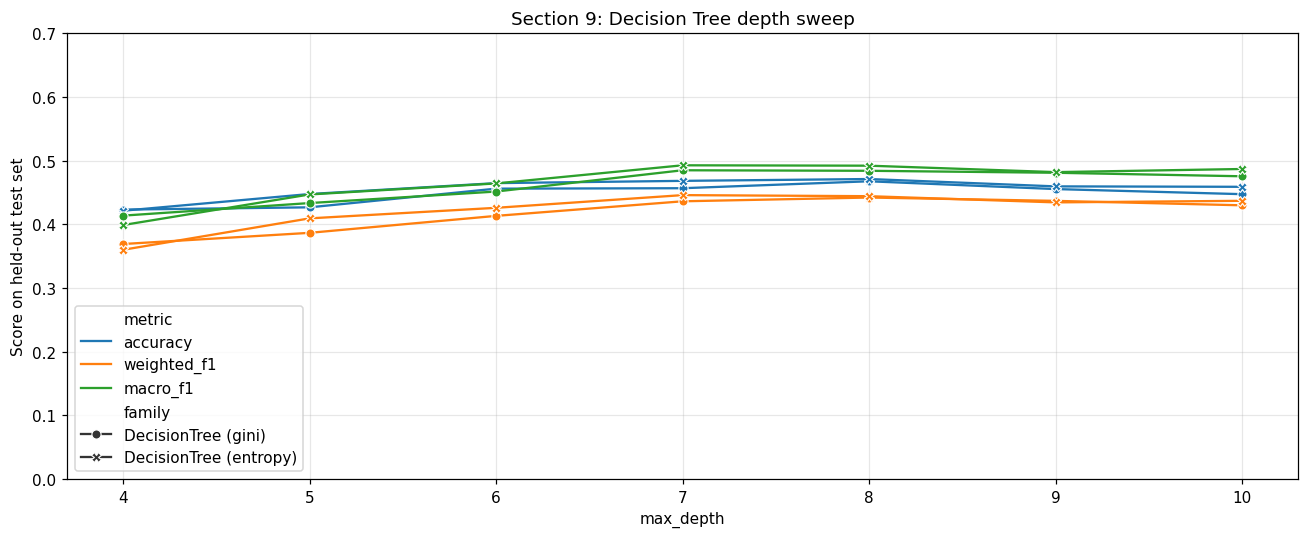

In [169]:
# Plot 1: Decision tree depth curves
dt_df = sweep_df[sweep_df["family"].str.contains("DecisionTree")].copy()
dt_long = dt_df.melt(
    id_vars=["family", "x_name", "x_value"],
    value_vars=["accuracy", "weighted_f1", "macro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5), dpi=DPI)
sns.lineplot(
    data=dt_long,
    x="x_value",
    y="score",
    hue="metric",
    style="family",
    markers=True,
    dashes=False,
)
plt.title("Section 9: Decision Tree depth sweep")
plt.xlabel("max_depth")
plt.ylabel("Score on held-out test set")
plt.ylim(0, 0.7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

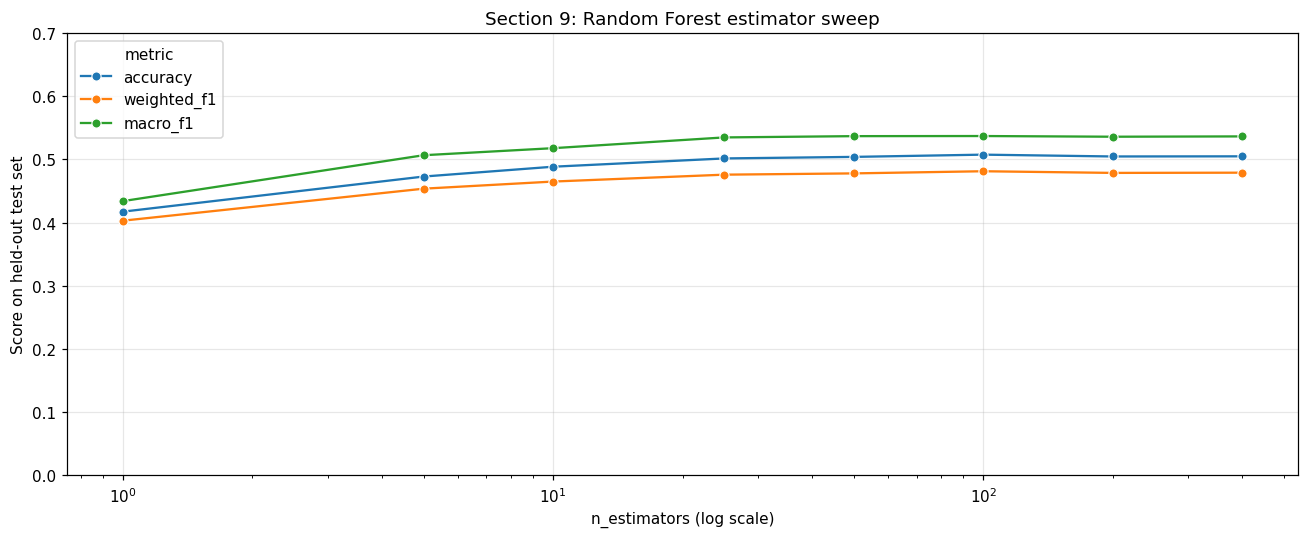

In [170]:
# Plot 2: Random forest estimator curves
rf_df = sweep_df[sweep_df["family"] == "RandomForest"].copy()
rf_long = rf_df.melt(
    id_vars=["family", "x_name", "x_value"],
    value_vars=["accuracy", "weighted_f1", "macro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5), dpi=DPI)
sns.lineplot(
    data=rf_long,
    x="x_value",
    y="score",
    hue="metric",
    marker="o",
)
plt.xscale("log")
plt.title("Section 9: Random Forest estimator sweep")
plt.xlabel("n_estimators (log scale)")
plt.ylabel("Score on held-out test set")
plt.ylim(0, 0.7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation and modeling direction

The sensitivity sweep supports the same model-selection conclusion reached earlier: **Random Forest remains the strongest family under weighted F1**, which is the best selection metric for this imbalanced multiclass task.

From the live results, single Decision Trees improve up to moderate depth and then flatten or decline (consistent with overfitting at higher depth). In contrast, Random Forest improves substantially as estimators increase from 1 to about 50-100, then shows diminishing returns beyond that point. On this split, the strongest Random Forest settings are near **100 estimators** by weighted F1 and macro F1, while 200-400 estimators provide little additional benefit.

As a next step, this evidence motivates a 5-fold stratified cross-validation tuning pass centered on Random Forest (`n_estimators`, `max_depth`, `min_samples_leaf`, and `class_weight="balanced"`) scored by weighted F1, with macro F1 and per-class F1 used to verify minority-class behavior.